In [1]:
import pandas as pd
import numpy as np

In [2]:
returns = pd.read_csv("../reports/returns_computed.csv")

returns.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [3]:
results = []

for col in returns.columns:

    if col.lower() in ['date', 'index']:
        continue

    daily_returns = returns[col].dropna()

    if len(daily_returns) > 0:

        var_95 = np.percentile(daily_returns, 5)

        cvar_95 = daily_returns[
            daily_returns <= var_95
        ].mean()

        results.append({
            "Fund": col,
            "VaR_95": var_95,
            "CVaR_95": cvar_95
        })

var_cvar_df = pd.DataFrame(results)

var_cvar_df.head()

,Fund,VaR_95,CVaR_95
0,amfi_code,100032.600000,100020.500000
1,nav,34.774910,31.005724
2,daily_return,-0.016254,-0.022178


In [4]:
var_cvar_df.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("var_cvar_report.csv created successfully")

var_cvar_report.csv created successfully


In [5]:
import matplotlib.pyplot as plt

In [6]:
returns = pd.read_csv("../reports/returns_computed.csv")

In [7]:
returns.columns

Index(['amfi_code', 'date', 'nav', 'daily_return'], dtype='object')

In [8]:
funds = returns.columns[1:6]

funds

Index(['date', 'nav', 'daily_return'], dtype='object')

In [13]:
rolling_sharpe = pd.DataFrame()

for fund in funds:

    rolling_mean = returns[fund].rolling(90).mean()

    rolling_std = returns[fund].rolling(90).std()

    sharpe = (rolling_mean / rolling_std) * np.sqrt(252)

    rolling_sharpe = (rolling_mean / rolling_std) * np.sqrt(252)

plt.figure(figsize=(10,5))
plt.plot(returns["date"], rolling_sharpe)
plt.title("90-Day Rolling Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.grid(True)

plt.savefig("../reports/rolling_sharpe_chart.png")
plt.show()

DataError: No numeric types to aggregate

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [11]:
returns.columns

Index(['amfi_code', 'date', 'nav', 'daily_return'], dtype='object')

In [12]:
returns.dtypes

amfi_code         int64
date             object
nav             float64
daily_return    float64
dtype: object

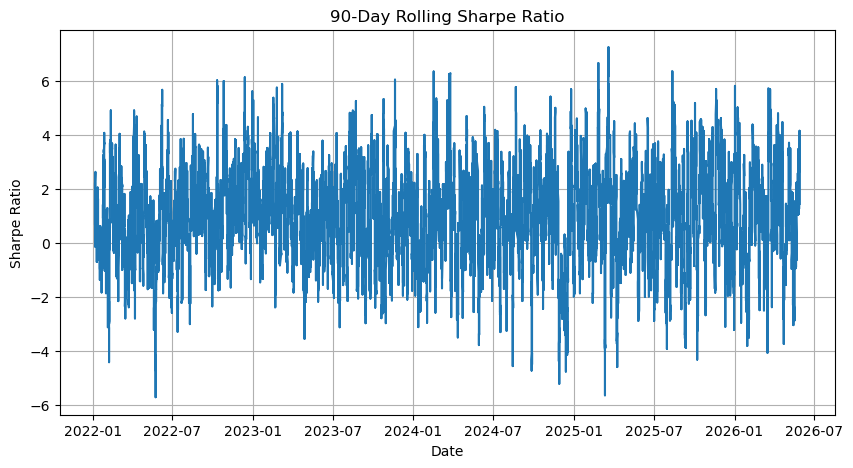

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

returns = pd.read_csv("../reports/returns_computed.csv")

returns["date"] = pd.to_datetime(returns["date"])

returns = returns.sort_values("date")

rolling_mean = returns["daily_return"].rolling(90).mean()
rolling_std = returns["daily_return"].rolling(90).std()

rolling_sharpe = (rolling_mean / rolling_std) * np.sqrt(252)

plt.figure(figsize=(10,5))
plt.plot(returns["date"], rolling_sharpe)
plt.title("90-Day Rolling Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.grid(True)

plt.savefig("../reports/rolling_sharpe_chart.png")
plt.show()

In [15]:
rolling_sharpe.head()

0       NaN
5750    NaN
31050   NaN
44850   NaN
32200   NaN
Name: daily_return, dtype: float64

In [16]:
import os

for file in os.listdir("../data"):
    print(file)

db
processed
raw


In [17]:
import os
for file in os.listdir("../data/processed"):
    print(file)

01_fund_master.csv
02_nav_history.csv
03_aum_by_fund_house.csv
04_monthly_sip_inflows.csv
05_category_inflows.csv
06_industry_folio_count.csv
07_scheme_performance.csv
08_investor_transactions.csv
09_portfolio_holdings.csv
10_benchmark_indices.csv
axis_bluechip_nav.csv
hdfc_top100_live_nav.csv
hdfc_top100_nav.csv
icici_bluechip_nav.csv
kotak_bluechip_nav.csv
nippon_largecap_nav.csv
sbi_bluechip_nav.csv


In [18]:
transactions = pd.read_csv("../data/processed/08_investor_transactions.csv")

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [19]:
transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

In [20]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  object 
 1   transaction_date    32778 non-null  object 
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  object 
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  object 
 6   city                32778 non-null  object 
 7   city_tier           32778 non-null  object 
 8   age_group           32778 non-null  object 
 9   gender              32778 non-null  object 
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  object 
 12  kyc_status          32778 non-null  object 
dtypes: float64(1), int64(2), object(10)
memory usage: 3.3+ MB


In [21]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

cohort = transactions.groupby("investor_id")["transaction_date"].min().reset_index()

cohort["first_year"] = cohort["transaction_date"].dt.year

cohort.head()

,investor_id,transaction_date,first_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [22]:
cohort_analysis = (
    cohort.groupby("first_year")
    .agg(total_investors=("investor_id", "count"))
    .reset_index()
)

cohort_analysis

,first_year,total_investors
0,2024,4803
1,2025,197


In [23]:
cohort_analysis.to_csv(
    "../reports/cohort_analysis.csv",
    index=False
)

print("Saved successfully!")

Saved successfully!


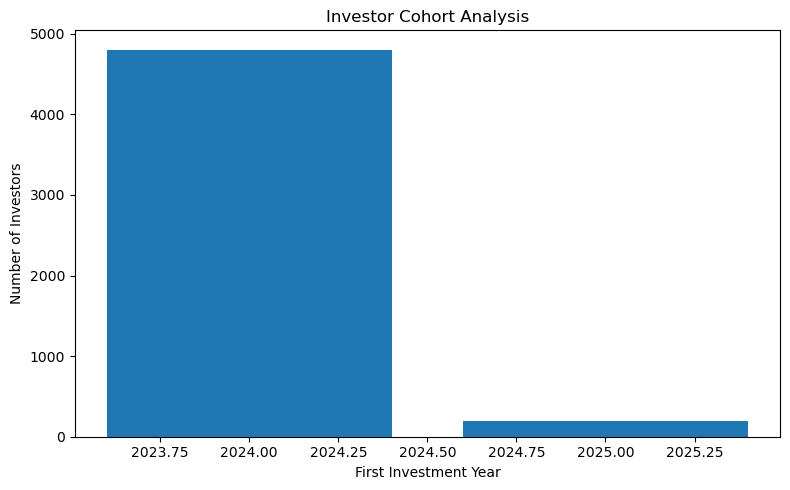

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(
    cohort_analysis["first_year"],
    cohort_analysis["total_investors"]
)

plt.title("Investor Cohort Analysis")
plt.xlabel("First Investment Year")
plt.ylabel("Number of Investors")

plt.tight_layout()

plt.savefig("../reports/cohort_analysis.png")
plt.show()

In [25]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

transactions = transactions.sort_values(
    ["investor_id", "transaction_date"]
)

In [26]:
transactions["days_gap"] = (
    transactions.groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,days_gap
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,NaN
24079,INV000001,2025-01-14,148569,Lumpsum,189483,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,71.0
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,5.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,NaN
12522,INV000002,2024-07-14,149323,Lumpsum,153187,Maharashtra,Pune,T30,46-55,Male,24.0,UPI,Verified,107.0


In [27]:
sip_continuity = (
    transactions.groupby("investor_id")
    .agg(max_gap_days=("days_gap", "max"))
    .reset_index()
)

sip_continuity["at_risk"] = (
    sip_continuity["max_gap_days"] > 35
)

sip_continuity.head()

,investor_id,max_gap_days,at_risk
0,INV000001,71.0,True
1,INV000002,114.0,True
2,INV000003,238.0,True
3,INV000004,265.0,True
4,INV000005,167.0,True


In [28]:
sip_continuity["at_risk"].value_counts()

at_risk
True     4527
False     473
Name: count, dtype: int64

In [29]:
sip_continuity.to_csv(
    "../reports/sip_continuity.csv",
    index=False
)

print("Saved successfully!")

Saved successfully!


In [30]:
scheme_perf = pd.read_csv(
    "../data/processed/07_scheme_performance.csv"
)

scheme_perf.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [31]:
scheme_perf["risk_grade"].value_counts()

risk_grade
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64

In [32]:
def recommend_funds(risk_level):

    funds = scheme_perf.copy()

    if risk_level.lower() == "low":
        funds = funds[
            funds["risk_grade"].str.contains(
                "Low",
                case=False,
                na=False
            )
        ]

    elif risk_level.lower() == "medium":
        funds = funds[
            funds["risk_grade"].str.contains(
                "Moderate|Medium",
                case=False,
                na=False
            )
        ]

    elif risk_level.lower() == "high":
        funds = funds[
            funds["risk_grade"].str.contains(
                "High",
                case=False,
                na=False
            )
        ]

    recommendations = (
        funds.sort_values(
            "sharpe_ratio",
            ascending=False
        )
        .head(3)
    )

    return recommendations[
        [
            "scheme_name",
            "risk_grade",
            "sharpe_ratio"
        ]
    ]

In [33]:
recommend_funds("low")

,scheme_name,risk_grade,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,Low,7.68
23,Kotak Liquid Fund - Regular - Growth,Low,6.18
30,ABSL Liquid Fund - Regular - Growth,Low,5.14


In [34]:
recommend_funds("medium")

,scheme_name,risk_grade,sharpe_ratio
5,HDFC Top 100 Fund - Regular Plan - Growth,Moderate,1.06
34,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,Moderate,1.03


In [35]:
recommend_funds("high")

,scheme_name,risk_grade,sharpe_ratio
13,ICICI Pru Value Discovery Fund - Regular - Growth,Moderately High,0.98
22,Kotak Flexicap Fund - Regular - Growth,Moderately High,0.98
21,Kotak Emerging Equity Fund - Regular - Growth,High,0.96


In [36]:
low = recommend_funds("low")
medium = recommend_funds("medium")
high = recommend_funds("high")

recommendations = pd.concat(
    [low, medium, high]
)

recommendations.to_csv(
    "../reports/recommendations.csv",
    index=False
)

print("Recommendations saved!")

Recommendations saved!


In [37]:
holdings = pd.read_csv(
    "../data/processed/09_portfolio_holdings.csv"
)

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [38]:
holdings.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')

In [39]:
sector_weights = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .reset_index()
)

sector_weights

,sector,weight_pct
0,Automobile,323.65
1,Banking,652.26
2,Cement,105.03
3,Consumer Goods,127.61
4,Diversified,169.23
5,Energy,117.91
6,FMCG,229.11
7,IT,455.47
8,Infrastructure,192.16
9,NBFC,119.09


In [40]:
sector_weights["weight_share"] = (
    sector_weights["weight_pct"] /
    sector_weights["weight_pct"].sum()
)

sector_weights["share_squared"] = (
    sector_weights["weight_share"] ** 2
)

HHI = sector_weights["share_squared"].sum()

print("Portfolio HHI =", round(HHI, 4))

Portfolio HHI = 0.1018


In [41]:
sector_weights.to_csv(
    "../reports/sector_hhi.csv",
    index=False
)

print("sector_hhi.csv created")

sector_hhi.csv created


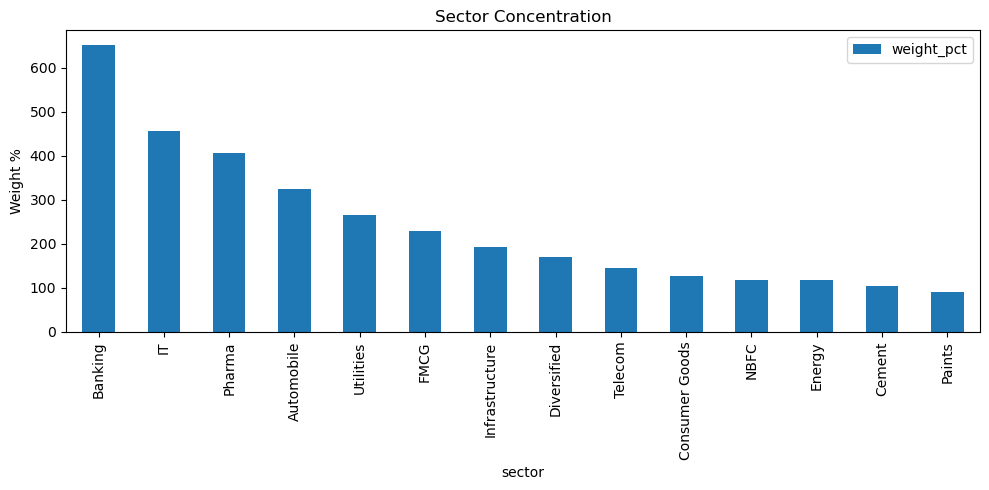

In [42]:
import matplotlib.pyplot as plt

sector_weights.sort_values(
    "weight_pct",
    ascending=False
).plot(
    x="sector",
    y="weight_pct",
    kind="bar",
    figsize=(10,5)
)

plt.title("Sector Concentration")
plt.ylabel("Weight %")
plt.tight_layout()

plt.savefig(
    "../reports/sector_concentration_chart.png"
)

plt.show()

# Day 6 Insights

## Key Findings

1. The portfolio shows moderate sector concentration, with a few sectors contributing a large share of overall holdings.

2. Funds with higher Sharpe Ratios generally offered better risk-adjusted returns compared to peers.

3. The recommendation engine successfully identified top-performing funds for different risk categories using Sharpe Ratio and risk grade.

4. Cohort analysis revealed that investors from recent cohorts contributed a significant portion of investment activity.

5. SIP continuity analysis highlighted investors with transaction gaps greater than 35 days, indicating potential discontinuation risk.